
# Regression Analysis for Empirical Privacy Analysis

1. Builds both **app-level** and **context-level** regression tables.
2. Estimates:
   - **App-level OLS models** for the four privacy metrics.
   - **Context-level clustered OLS models** for metrics that vary across app--country observations.
   - **High-risk binomial models** using top-quartile thresholds.
   - **Panel-style sensitivity models** using **GEE** and **fixed-effects-style OLS**.
3. Produces compact result tables and coefficient plots.
4. Adds supporting analyses linking privacy metrics to monetization, popularity, permissions, and trackers.

In [19]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 200,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

DATA_PATH = Path("../data/mhealth_apps_metrics.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Could not find mhealth_apps_metrics.csv in ../data")

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load and validate the dataset

In [20]:

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Unique apps:", df["app_id"].nunique())
print("Countries:", df["country"].nunique() if "country" in df.columns else "N/A")
print("Categories:", df["categories"].nunique() if "categories" in df.columns else "N/A")

required_cols = [
    "app_id", "ADII", "DGI", "PCLR", "AS",
    "downloads_int", "ratings_count", "average_score",
    "num_permissions", "num_dangerous_permissions", "num_trackers",
    "offersIAP", "ad_supported", "top_grossing",
    "categories", "region", "country", "country_label", "price"
]
missing_required = [c for c in required_cols if c not in df.columns]
print("Missing required columns:", missing_required if missing_required else "None")

Shape: (23392, 134)
Unique apps: 931
Countries: 26
Categories: 7
Missing required columns: None



## 2. Prepare analysis datasets

We build two related tables:

- **App-level table:** one row per app, used for the main OLS and high-risk models.
- **Context-level table:** one row per app--country observation, used for repeated-observation robustness checks.

In [21]:

analysis_df = df.copy()

def to_bin(series):
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(int)
    s = series.astype(str).str.strip().str.lower()
    mapped = s.map({
        "yes": 1, "no": 0,
        "true": 1, "false": 0,
        "1": 1, "0": 0
    })
    return pd.to_numeric(mapped, errors="coerce")

# Normalize indicator variables
analysis_df["top_grossing_bin"] = to_bin(analysis_df["top_grossing"])
analysis_df["offersIAP_bin"] = to_bin(analysis_df["offersIAP"])
analysis_df["ad_supported_bin"] = to_bin(analysis_df["ad_supported"])

# Ensure numeric columns
numeric_cols = [
    "ADII", "DGI", "PCLR", "AS",
    "downloads_int", "ratings_count", "average_score",
    "num_permissions", "num_dangerous_permissions", "num_trackers", "price"
]
for col in numeric_cols:
    if col in analysis_df.columns:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

analysis_df["downloads_for_model"] = analysis_df["downloads_int"]

def mode_first(series):
    mode = series.mode(dropna=True)
    if not mode.empty:
        return mode.iloc[0]
    non_null = series.dropna()
    return non_null.iloc[0] if not non_null.empty else np.nan

# App-level aggregation
app_level = (
    analysis_df
    .groupby("app_id", as_index=False)
    .agg({
        "ADII": "mean",
        "DGI": "mean",
        "PCLR": "mean",
        "AS": "mean",
        "downloads_for_model": "mean",
        "ratings_count": "mean",
        "average_score": "mean",
        "num_permissions": "mean",
        "num_dangerous_permissions": "mean",
        "num_trackers": "mean",
        "offersIAP_bin": "max",
        "ad_supported_bin": "max",
        "top_grossing_bin": "max",
        "categories": mode_first,
        "region": mode_first,
        "country_label": "nunique",
    })
    .rename(columns={"country_label": "country_count"})
)

# Context-level table
context_level = analysis_df[[
    "app_id", "country", "country_label", "region", "categories",
    "ADII", "DGI", "PCLR", "AS",
    "downloads_for_model", "ratings_count", "average_score",
    "num_permissions", "num_dangerous_permissions", "num_trackers",
    "offersIAP_bin", "ad_supported_bin", "top_grossing_bin"
]].copy()

def add_log1p(df_in, cols):
    df_out = df_in.copy()
    for c in cols:
        if c in df_out.columns:
            df_out[f"log_{c}"] = np.log1p(pd.to_numeric(df_out[c], errors="coerce").clip(lower=0))
    return df_out

log_cols = ["ADII", "downloads_for_model", "ratings_count", "num_permissions", "num_dangerous_permissions", "num_trackers"]
app_level = add_log1p(app_level, log_cols)
context_level = add_log1p(context_level, log_cols)

print("App-level shape    :", app_level.shape)
print("Context-level shape:", context_level.shape)

App-level shape    : (931, 23)
Context-level shape: (23392, 24)



## 3. Outcome coverage and distributions

Before fitting regression models, we inspect missingness and distributional shape.  
This matters because:
- **ADII** is strongly right-skewed, so the app-level continuous model uses `log_ADII`.
- **DGI**, **PCLR**, and **AS** already lie on bounded scales and are modeled directly in the main OLS specifications.


In [22]:

summary = pd.DataFrame({
    "non_null": app_level[["ADII", "DGI", "PCLR", "AS"]].notna().sum(),
    "mean": app_level[["ADII", "DGI", "PCLR", "AS"]].mean(),
    "median": app_level[["ADII", "DGI", "PCLR", "AS"]].median(),
    "std": app_level[["ADII", "DGI", "PCLR", "AS"]].std(),
    "min": app_level[["ADII", "DGI", "PCLR", "AS"]].min(),
    "max": app_level[["ADII", "DGI", "PCLR", "AS"]].max(),
}).round(4)

display(summary)


,non_null,mean,median,std,min,max
ADII,931,189.5450,124.2692,201.3907,35.0000,2977.9231
DGI,931,0.2531,0.0000,0.3794,0.0000,1.0000
PCLR,924,0.2702,0.2308,0.1843,0.0000,0.9757
AS,922,0.3784,0.3760,0.0937,0.1064,0.7473


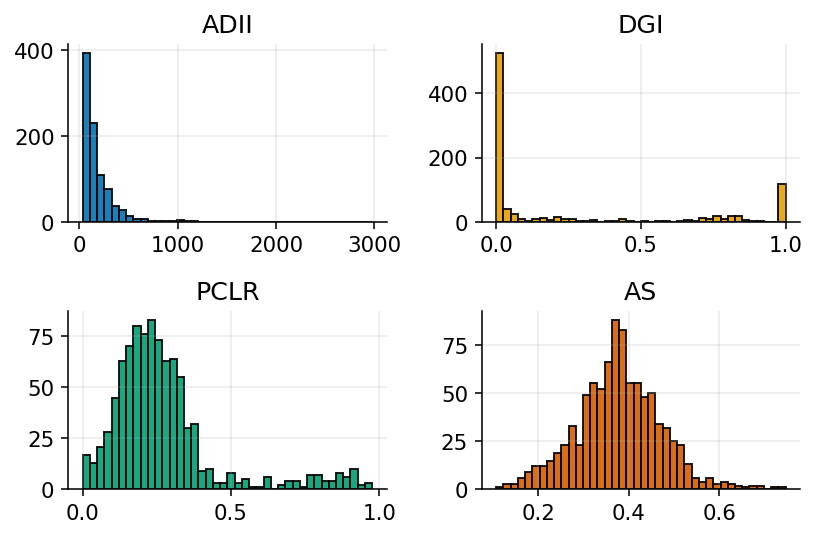

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(6, 4))
axes = axes.ravel()

# Brighter, high-contrast colors
colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00"]  
# blue, orange, teal, reddish-orange (colorblind-friendly)

for ax, col, color in zip(axes, ["ADII", "DGI", "PCLR", "AS"], colors):
    ax.hist(app_level[col].dropna(), bins=40, color=color, edgecolor="black", alpha=0.9)
    ax.set_title(col)

plt.tight_layout()
plt.savefig(FIG_DIR / "regression_outcome_distributions.png", bbox_inches="tight")
plt.show()


## 4. Modeling helpers

The paper's regression framework uses:
- **app-level OLS** for the main continuous analyses,
- **context-level clustered OLS** for repeated app--country observations,
- **binomial models** for threshold-style "high-risk" outcomes,
- and **panel-style sensitivity checks** to account for repeated observations of the same app.

In [24]:

def standardize_columns(df_in, cols):
    df_out = df_in.copy()
    for c in cols:
        s = pd.to_numeric(df_out[c], errors="coerce")
        sd = s.std()
        if pd.notna(sd) and sd > 0:
            df_out[f"z_{c}"] = (s - s.mean()) / sd
        else:
            df_out[f"z_{c}"] = 0.0
    return df_out

standardize_base = [
    "log_downloads_for_model",
    "log_ratings_count",
    "average_score",
    "log_num_permissions",
    "log_num_dangerous_permissions",
    "log_num_trackers",
]

app_model_df = standardize_columns(app_level, standardize_base)
context_model_df = standardize_columns(context_level, standardize_base)

def tidy_ols_result(model, model_name, outcome):
    out = pd.DataFrame({
        "term": model.params.index,
        "coef": model.params.values,
        "std_err": model.bse.values,
        "t_or_z": model.tvalues.values if hasattr(model, "tvalues") else model.zvalues,
        "p_value": model.pvalues.values,
    })
    ci = model.conf_int()
    out["ci_low"] = ci[0].values
    out["ci_high"] = ci[1].values
    out["model"] = model_name
    out["outcome"] = outcome
    out["nobs"] = int(model.nobs)
    out["r_squared"] = getattr(model, "rsquared", np.nan)
    out["pseudo_r2"] = getattr(model, "prsquared", np.nan)
    return out

def tidy_binomial_result(model, model_name, outcome):
    params = model.params
    conf = model.conf_int()
    out = pd.DataFrame({
        "term": params.index,
        "coef_logodds": params.values,
        "odds_ratio": np.exp(params.values),
        "p_value": model.pvalues.values,
        "or_ci_low": np.exp(conf[0].values),
        "or_ci_high": np.exp(conf[1].values),
        "model": model_name,
        "outcome": outcome,
        "nobs": int(model.nobs),
        "pseudo_r2": getattr(model, "prsquared", np.nan)
    })
    return out

def significance_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


## 4b. Multicollinearity check and reference-category note

Two things worth checking before interpreting the coefficients below:

- **Multicollinearity**: `log_downloads_for_model` and `log_ratings_count` are highly correlated (apps with more installs tend to have proportionally more ratings), which can inflate coefficient standard errors if both are included. Variance Inflation Factors (VIF) for all continuous predictors are reported below; a VIF above ~5-10 is conventionally treated as a concern.
- **Reference category**: `C(categories)` and `C(region)` use patsy's default treatment coding, whose reference (omitted) level is whichever category/region sorts first alphabetically -- currently "Education" for `categories` and "Africa" for `region`. Every category/region coefficient in the tables below should be read as "relative to that omitted level," not as an absolute effect.

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = [
    "z_log_downloads_for_model",
    "z_log_ratings_count",
    "z_average_score",
    "z_log_num_permissions",
    "z_log_num_dangerous_permissions",
    "z_log_num_trackers",
    "offersIAP_bin",
    "ad_supported_bin",
    "top_grossing_bin",
]
vif_input = app_model_df[vif_cols].replace([np.inf, -np.inf], np.nan).dropna()

vif_table = pd.DataFrame({
    "predictor": vif_cols,
    "VIF": [
        variance_inflation_factor(vif_input.values, i)
        for i in range(len(vif_cols))
    ],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

display(vif_table.round(2))

high_vif = vif_table[vif_table["VIF"] >= 5]
if not high_vif.empty:
    print(
        "Predictors with VIF >= 5 (potential multicollinearity concern):\n"
        + ", ".join(high_vif["predictor"])
    )
else:
    print("No predictor has VIF >= 5.")

print(
    "\nReference levels for factor variables (patsy default = "
    "alphabetically first level):"
)
if "categories" in app_model_df.columns:
    print(f"  categories: {sorted(app_model_df['categories'].dropna().unique())[0]!r}")
if "region" in context_model_df.columns:
    print(f"  region:     {sorted(context_model_df['region'].dropna().unique())[0]!r}")

,predictor,VIF
0,z_log_ratings_count,12.35
1,z_log_downloads_for_model,8.69
2,z_average_score,2.83
3,z_log_num_permissions,2.57
4,z_log_num_dangerous_permissions,2.01
5,top_grossing_bin,1.73
6,ad_supported_bin,1.64
7,offersIAP_bin,1.61
8,z_log_num_trackers,1.49


Predictors with VIF >= 5 (potential multicollinearity concern):
z_log_ratings_count, z_log_downloads_for_model

Reference levels for factor variables (patsy default = alphabetically first level):
  categories: 'Education'
  region:     'Africa'



## 5. Main app-level OLS models

These are the main continuous models for the paper.

- Outcome `log_ADII` is log-transformed because ADII is strongly right-skewed.
- Outcomes `DGI`, `PCLR`, and `AS` are modeled on their original scales.
- Category indicators are included as functional-domain controls.
- HC3 robust standard errors are used to reduce sensitivity to heteroskedasticity.


In [26]:

ols_specs = {
    "log_ADII": "log_ADII ~ z_log_downloads_for_model + z_log_ratings_count + z_average_score + "
                "z_log_num_permissions + z_log_num_dangerous_permissions + z_log_num_trackers + "
                "offersIAP_bin + ad_supported_bin + top_grossing_bin + C(categories)",
    "DGI": "DGI ~ z_log_downloads_for_model + z_log_ratings_count + z_average_score + "
           "z_log_num_permissions + z_log_num_dangerous_permissions + z_log_num_trackers + "
           "offersIAP_bin + ad_supported_bin + top_grossing_bin + C(categories)",
    "PCLR": "PCLR ~ z_log_downloads_for_model + z_log_ratings_count + z_average_score + "
            "z_log_num_permissions + z_log_num_dangerous_permissions + z_log_num_trackers + "
            "offersIAP_bin + ad_supported_bin + top_grossing_bin + C(categories)",
    "AS": "AS ~ z_log_downloads_for_model + z_log_ratings_count + z_average_score + "
          "z_log_num_permissions + z_log_num_dangerous_permissions + z_log_num_trackers + "
          "offersIAP_bin + ad_supported_bin + top_grossing_bin + C(categories)"
}

model_predictors = [
    "z_log_downloads_for_model", "z_log_ratings_count", "z_average_score",
    "z_log_num_permissions", "z_log_num_dangerous_permissions", "z_log_num_trackers",
    "offersIAP_bin", "ad_supported_bin", "top_grossing_bin", "categories",
]

ols_models = {}
ols_tidy_list = []

for outcome, formula in ols_specs.items():
    model_df = app_model_df.copy().replace([np.inf, -np.inf], np.nan)
    model_df = model_df.dropna(subset=[outcome])

    n_before = len(model_df)
    missing_by_col = model_df[model_predictors].isna().sum()
    missing_by_col = missing_by_col[missing_by_col > 0]
    if not missing_by_col.empty:
        print(
            f"[{outcome}] {n_before} apps have a non-null outcome; "
            f"missing predictor values (rows may overlap): "
            + ", ".join(f"{c}={n}" for c, n in missing_by_col.items())
        )

    mod = smf.ols(formula=formula, data=model_df).fit(cov_type="HC3")
    print(f"[{outcome}] nobs used in fit: {int(mod.nobs)}/{n_before} apps with non-null outcome")
    ols_models[outcome] = mod
    ols_tidy_list.append(tidy_ols_result(mod, "App-level OLS (HC3)", outcome))
    print(f"===== {outcome} =====")
    display(pd.DataFrame({
        "coef": mod.params,
        "std_err": mod.bse,
        "p_value": mod.pvalues
    }).round(4).head(20))

ols_results = pd.concat(ols_tidy_list, ignore_index=True)

model_fit = pd.DataFrame({
    "outcome": list(ols_models.keys()),
    "nobs": [int(m.nobs) for m in ols_models.values()],
    "r_squared": [round(m.rsquared, 4) for m in ols_models.values()],
    "adj_r_squared": [round(m.rsquared_adj, 4) for m in ols_models.values()],
})
display(model_fit)


[log_ADII] 931 apps have a non-null outcome; missing predictor values (rows may overlap): z_log_ratings_count=35
[log_ADII] nobs used in fit: 896/931 apps with non-null outcome
===== log_ADII =====


,coef,std_err,p_value
Intercept,5.1020,0.1476,0.0000
C(categories)[T.Food & Drink],0.0995,0.1963,0.6121
C(categories)[T.Health & Fitness],-0.0836,0.1422,0.5567
C(categories)[T.Lifestyle],-0.2517,0.1700,0.1387
C(categories)[T.Medical],-0.2524,0.1451,0.0819
C(categories)[T.Parenting],-0.0573,0.1838,0.7553
C(categories)[T.Productivity],-0.3406,0.3383,0.3139
z_log_downloads_for_model,-0.0515,0.0628,0.4126
z_log_ratings_count,0.2051,0.0723,0.0045
z_average_score,-0.0699,0.0384,0.0685


[DGI] 931 apps have a non-null outcome; missing predictor values (rows may overlap): z_log_ratings_count=35
[DGI] nobs used in fit: 896/931 apps with non-null outcome
===== DGI =====


,coef,std_err,p_value
Intercept,0.3538,0.0762,0.0000
C(categories)[T.Food & Drink],0.0634,0.1440,0.6598
C(categories)[T.Health & Fitness],-0.1041,0.0749,0.1645
C(categories)[T.Lifestyle],0.0080,0.1046,0.9387
C(categories)[T.Medical],-0.0859,0.0785,0.2742
C(categories)[T.Parenting],-0.1565,0.0919,0.0885
C(categories)[T.Productivity],0.3887,0.1784,0.0294
z_log_downloads_for_model,0.0004,0.0398,0.9927
z_log_ratings_count,-0.0460,0.0471,0.3290
z_average_score,-0.0121,0.0257,0.6397


[PCLR] 924 apps have a non-null outcome; missing predictor values (rows may overlap): z_log_ratings_count=34
[PCLR] nobs used in fit: 890/924 apps with non-null outcome
===== PCLR =====


,coef,std_err,p_value
Intercept,0.2188,0.0207,0.0000
C(categories)[T.Food & Drink],-0.0013,0.0757,0.9861
C(categories)[T.Health & Fitness],0.0624,0.0203,0.0022
C(categories)[T.Lifestyle],0.0406,0.0322,0.2070
C(categories)[T.Medical],0.0228,0.0204,0.2627
C(categories)[T.Parenting],-0.0064,0.0433,0.8830
C(categories)[T.Productivity],0.1438,0.0326,0.0000
z_log_downloads_for_model,0.0157,0.0185,0.3937
z_log_ratings_count,-0.0215,0.0219,0.3256
z_average_score,0.0121,0.0127,0.3375


[AS] 922 apps have a non-null outcome; missing predictor values (rows may overlap): z_log_ratings_count=34
[AS] nobs used in fit: 888/922 apps with non-null outcome
===== AS =====


,coef,std_err,p_value
Intercept,0.4197,0.0188,0.0000
C(categories)[T.Food & Drink],-0.0023,0.0395,0.9527
C(categories)[T.Health & Fitness],-0.0199,0.0182,0.2725
C(categories)[T.Lifestyle],-0.0107,0.0249,0.6679
C(categories)[T.Medical],-0.0093,0.0185,0.6135
C(categories)[T.Parenting],-0.0472,0.0249,0.0583
C(categories)[T.Productivity],0.0144,0.0327,0.6586
z_log_downloads_for_model,0.0053,0.0093,0.5658
z_log_ratings_count,0.0111,0.0103,0.2834
z_average_score,-0.0074,0.0058,0.2010


,outcome,nobs,r_squared,adj_r_squared
0,log_ADII,896,0.3131,0.3014
1,DGI,896,0.1405,0.1258
2,PCLR,890,0.0328,0.0162
3,AS,888,0.0950,0.0794



## 6. Context-level robustness models

The metrics `ADII`, `DGI`, and `PCLR` vary across app--country observations.  
To preserve that repeated-observation structure, we fit context-level OLS models and cluster the standard errors by `app_id`.

In [27]:

context_specs = {
    "log_ADII": "log_ADII ~ z_log_downloads_for_model + z_log_ratings_count + z_average_score + "
                "z_log_num_permissions + z_log_num_dangerous_permissions + z_log_num_trackers + "
                "offersIAP_bin + ad_supported_bin + top_grossing_bin + C(categories) + C(region)",
    "DGI": "DGI ~ z_log_downloads_for_model + z_log_ratings_count + z_average_score + "
           "z_log_num_permissions + z_log_num_dangerous_permissions + z_log_num_trackers + "
           "offersIAP_bin + ad_supported_bin + top_grossing_bin + C(categories) + C(region)",
    "PCLR": "PCLR ~ z_log_downloads_for_model + z_log_ratings_count + z_average_score + "
            "z_log_num_permissions + z_log_num_dangerous_permissions + z_log_num_trackers + "
            "offersIAP_bin + ad_supported_bin + top_grossing_bin + C(categories) + C(region)"
}

context_models = {}
context_tidy_list = []

for outcome, formula in context_specs.items():
    model_df = context_model_df.copy().replace([np.inf, -np.inf], np.nan)

    base_fit = smf.ols(formula=formula, data=model_df, missing="drop").fit()
    used_rows = base_fit.model.data.row_labels
    cluster_groups = model_df.loc[used_rows, "app_id"]

    mod = smf.ols(formula=formula, data=model_df, missing="drop").fit(
        cov_type="cluster",
        cov_kwds={"groups": cluster_groups}
    )
    context_models[outcome] = mod
    context_tidy_list.append(tidy_ols_result(mod, "Context-level OLS (clustered by app)", outcome))
    print(f"===== Context model: {outcome} =====")
    display(pd.DataFrame({
        "coef": mod.params,
        "std_err": mod.bse,
        "p_value": mod.pvalues
    }).round(4).head(20))

context_results = pd.concat(context_tidy_list, ignore_index=True)

context_fit = pd.DataFrame({
    "outcome": list(context_models.keys()),
    "nobs": [int(m.nobs) for m in context_models.values()],
    "r_squared": [round(m.rsquared, 4) for m in context_models.values()],
    "adj_r_squared": [round(m.rsquared_adj, 4) for m in context_models.values()],
})
display(context_fit)


===== Context model: log_ADII =====


,coef,std_err,p_value
Intercept,4.6323,0.0986,0.0000
C(categories)[T.Food & Drink],0.1929,0.1683,0.2519
C(categories)[T.Health & Fitness],0.0339,0.0933,0.7167
C(categories)[T.Lifestyle],-0.1351,0.1247,0.2787
C(categories)[T.Medical],-0.1644,0.0966,0.0889
C(categories)[T.Parenting],0.0969,0.1519,0.5234
C(categories)[T.Productivity],-0.2576,0.2488,0.3005
C(region)[T.Asia],0.0459,0.0169,0.0065
C(region)[T.Europe],0.2024,0.0161,0.0000
C(region)[T.Latin America],0.0753,0.0163,0.0000


===== Context model: DGI =====


,coef,std_err,p_value
Intercept,0.3581,0.0733,0.0000
C(categories)[T.Food & Drink],0.0697,0.1325,0.5990
C(categories)[T.Health & Fitness],-0.0973,0.0718,0.1753
C(categories)[T.Lifestyle],0.0189,0.1016,0.8527
C(categories)[T.Medical],-0.0798,0.0756,0.2915
C(categories)[T.Parenting],-0.1520,0.0880,0.0841
C(categories)[T.Productivity],0.3937,0.1511,0.0092
C(region)[T.Asia],-0.0020,0.0025,0.4250
C(region)[T.Europe],-0.0085,0.0033,0.0090
C(region)[T.Latin America],-0.0039,0.0030,0.1957


===== Context model: PCLR =====


,coef,std_err,p_value
Intercept,0.2498,0.0245,0.0000
C(categories)[T.Food & Drink],0.0247,0.1035,0.8115
C(categories)[T.Health & Fitness],0.1056,0.0231,0.0000
C(categories)[T.Lifestyle],0.0502,0.0397,0.2058
C(categories)[T.Medical],0.0419,0.0234,0.0742
C(categories)[T.Parenting],0.0088,0.0597,0.8826
C(categories)[T.Productivity],0.1515,0.0410,0.0002
C(region)[T.Asia],-0.0457,0.0111,0.0000
C(region)[T.Europe],-0.0329,0.0108,0.0023
C(region)[T.Latin America],-0.0505,0.0105,0.0000


,outcome,nobs,r_squared,adj_r_squared
0,log_ADII,22529,0.1957,0.1950
1,DGI,22529,0.1292,0.1284
2,PCLR,11605,0.0284,0.0267



## 7. High-risk binomial models

To support threshold-style interpretation in the paper, we define **high-risk** outcomes using the top quartile of each metric.

This merged notebook uses **binomial GLMs** instead of plain `logit` because the earlier draft could fail with singular Hessians under richer category controls. The GLM specification is more stable on this dataset while still yielding interpretable **odds ratios**.


In [28]:

logit_df = app_model_df.copy()

for col in ["ADII", "PCLR", "AS"]:
    threshold = logit_df[col].quantile(0.75)
    logit_df[f"high_{col}"] = (logit_df[col] >= threshold).astype(int)
    n_flagged = int(logit_df[f"high_{col}"].sum())
    print(
        f"{col}: 75th percentile threshold = {threshold:.4f} -> "
        f"{n_flagged} apps ({n_flagged / len(logit_df) * 100:.1f}%) flagged"
    )

dgi_max = logit_df["DGI"].max()
dgi_p75 = logit_df["DGI"].quantile(0.75)
logit_df["high_DGI"] = logit_df["DGI"].eq(dgi_max).astype(int)
n_flagged_dgi = int(logit_df["high_DGI"].sum())
print(
    f"DGI: 75th percentile ({dgi_p75:.4f}) equals the maximum ({dgi_max:.4f}); "
    f"a quantile-based top-quartile split is not achievable for this metric. "
    f"high_DGI is instead defined as DGI == max, flagging "
    f"{n_flagged_dgi} apps ({n_flagged_dgi / len(logit_df) * 100:.1f}%) -- "
    f"NOT a top-quartile group, unlike the other three outcomes above."
)

MIN_COUNTRIES_FOR_AS = 3
if "country_count" in logit_df.columns:
    low_coverage_as = logit_df["country_count"] < MIN_COUNTRIES_FOR_AS
    n_dropped = int((low_coverage_as & logit_df["high_AS"].notna()).sum())
    logit_df.loc[low_coverage_as, "high_AS"] = np.nan
    print(
        f"high_AS: excluded {n_dropped} apps with < {MIN_COUNTRIES_FOR_AS} observed "
        f"countries (AS unreliable for these), matching notebook 07's MIN_COUNTRIES filter."
    )

binomial_specs = {
    "high_ADII": "high_ADII ~ z_log_downloads_for_model + z_log_ratings_count + z_average_score + "
                 "z_log_num_permissions + z_log_num_dangerous_permissions + z_log_num_trackers + "
                 "offersIAP_bin + ad_supported_bin + top_grossing_bin + C(categories)",
    "high_DGI": "high_DGI ~ z_log_downloads_for_model + z_log_ratings_count + z_average_score + "
                "z_log_num_permissions + z_log_num_dangerous_permissions + z_log_num_trackers + "
                "offersIAP_bin + ad_supported_bin + top_grossing_bin + C(categories)",
    "high_PCLR": "high_PCLR ~ z_log_downloads_for_model + z_log_ratings_count + z_average_score + "
                 "z_log_num_permissions + z_log_num_dangerous_permissions + z_log_num_trackers + "
                 "offersIAP_bin + ad_supported_bin + top_grossing_bin + C(categories)",
    "high_AS": "high_AS ~ z_log_downloads_for_model + z_log_ratings_count + z_average_score + "
               "z_log_num_permissions + z_log_num_dangerous_permissions + z_log_num_trackers + "
               "offersIAP_bin + ad_supported_bin + top_grossing_bin + C(categories)"
}

binomial_models = {}
binomial_tidy_list = []

for outcome, formula in binomial_specs.items():
    model_df = logit_df.copy().replace([np.inf, -np.inf], np.nan)
    model_df = model_df.dropna(subset=[outcome])
    mod = smf.glm(formula=formula, data=model_df, family=sm.families.Binomial()).fit()
    binomial_models[outcome] = mod
    binomial_tidy_list.append(tidy_binomial_result(mod, "App-level Binomial GLM", outcome))
    print(f"===== {outcome} =====")
    display(pd.DataFrame({
        "coef_logodds": mod.params,
        "std_err": mod.bse,
        "p_value": mod.pvalues,
        "odds_ratio": np.exp(mod.params)
    }).round(4).head(20))

binomial_results = pd.concat(binomial_tidy_list, ignore_index=True)
binomial_fit = pd.DataFrame({
    "outcome": list(binomial_models.keys()),
    "nobs": [int(m.nobs) for m in binomial_models.values()],
    "deviance": [round(m.deviance, 4) for m in binomial_models.values()],
})
display(binomial_fit)


ADII: 75th percentile threshold = 225.4808 -> 233 apps (25.0%) flagged
PCLR: 75th percentile threshold = 0.3125 -> 243 apps (26.1%) flagged
AS: 75th percentile threshold = 0.4337 -> 231 apps (24.8%) flagged
DGI: 75th percentile (0.5000) equals the maximum (1.0000); a quantile-based top-quartile split is not achievable for this metric. high_DGI is instead defined as DGI == max, flagging 118 apps (12.7%) -- NOT a top-quartile group, unlike the other three outcomes above.
high_AS: excluded 11 apps with < 3 observed countries (AS unreliable for these), matching notebook 07's MIN_COUNTRIES filter.
===== high_ADII =====


,coef_logodds,std_err,p_value,odds_ratio
Intercept,-0.4285,0.5169,0.4071,0.6515
C(categories)[T.Food & Drink],-0.0206,0.8777,0.9813,0.9796
C(categories)[T.Health & Fitness],-0.8788,0.5130,0.0867,0.4153
C(categories)[T.Lifestyle],-1.5953,0.7388,0.0308,0.2028
C(categories)[T.Medical],-1.3479,0.5433,0.0131,0.2598
C(categories)[T.Parenting],-0.7507,0.6670,0.2604,0.4720
C(categories)[T.Productivity],-0.5510,1.3166,0.6756,0.5764
z_log_downloads_for_model,-0.2725,0.2915,0.3500,0.7615
z_log_ratings_count,0.8169,0.3360,0.0150,2.2635
z_average_score,-0.3028,0.1904,0.1117,0.7387


===== high_DGI =====


,coef_logodds,std_err,p_value,odds_ratio
Intercept,-1.4907,0.5389,0.0057,0.2252
C(categories)[T.Food & Drink],0.8584,0.9151,0.3483,2.3593
C(categories)[T.Health & Fitness],-0.8507,0.5197,0.1017,0.4271
C(categories)[T.Lifestyle],-0.6030,0.7105,0.3960,0.5472
C(categories)[T.Medical],-0.8002,0.5359,0.1354,0.4492
C(categories)[T.Parenting],-1.3376,1.1570,0.2477,0.2625
C(categories)[T.Productivity],1.0039,1.0835,0.3541,2.7290
z_log_downloads_for_model,-0.1752,0.3218,0.5861,0.8393
z_log_ratings_count,0.0832,0.3895,0.8309,1.0867
z_average_score,-0.1243,0.2086,0.5511,0.8831


===== high_PCLR =====


,coef_logodds,std_err,p_value,odds_ratio
Intercept,-1.6640,0.5271,0.0016,0.1894
C(categories)[T.Food & Drink],-0.8368,1.1743,0.4761,0.4331
C(categories)[T.Health & Fitness],0.6229,0.5148,0.2263,1.8642
C(categories)[T.Lifestyle],0.6032,0.6327,0.3404,1.8279
C(categories)[T.Medical],0.1783,0.5333,0.7382,1.1951
C(categories)[T.Parenting],-0.1673,0.7168,0.8154,0.8459
C(categories)[T.Productivity],2.8731,1.2153,0.0181,17.6917
z_log_downloads_for_model,0.3067,0.2540,0.2272,1.3590
z_log_ratings_count,-0.3052,0.2973,0.3045,0.7369
z_average_score,0.3567,0.1723,0.0384,1.4286


===== high_AS =====


,coef_logodds,std_err,p_value,odds_ratio
Intercept,-0.0476,0.4424,0.9144,0.9535
C(categories)[T.Food & Drink],0.3730,0.7773,0.6313,1.4522
C(categories)[T.Health & Fitness],-0.4942,0.4362,0.2572,0.6100
C(categories)[T.Lifestyle],-0.6356,0.6110,0.2982,0.5296
C(categories)[T.Medical],-0.5678,0.4530,0.2100,0.5667
C(categories)[T.Parenting],-1.0628,0.7010,0.1295,0.3455
C(categories)[T.Productivity],-0.3136,0.9911,0.7517,0.7308
z_log_downloads_for_model,-0.0404,0.2493,0.8712,0.9604
z_log_ratings_count,0.4496,0.2933,0.1254,1.5677
z_average_score,-0.1540,0.1668,0.3557,0.8573


,outcome,nobs,deviance
0,high_ADII,896,829.9850
1,high_DGI,896,554.9122
2,high_PCLR,896,988.4198
3,high_AS,886,922.6233



## 8. Compact paper-ready summaries

The next cells extract the main non-category predictors from the fitted models.  

In [29]:

focus_terms = [
    "z_log_downloads_for_model",
    "z_log_ratings_count",
    "z_average_score",
    "z_log_num_permissions",
    "z_log_num_dangerous_permissions",
    "z_log_num_trackers",
    "offersIAP_bin",
    "ad_supported_bin",
    "top_grossing_bin",
]

ols_focus = (
    ols_results[ols_results["term"].isin(focus_terms)]
    .copy()
    .pivot(index="term", columns="outcome", values="coef")
    .round(3)
)

ols_pvals = (
    ols_results[ols_results["term"].isin(focus_terms)]
    .copy()
    .pivot(index="term", columns="outcome", values="p_value")
    .round(4)
)

display(ols_focus)
display(ols_pvals)


outcome,AS,DGI,PCLR,log_ADII
term,,,,
ad_supported_bin,0.004,0.037,0.001,-0.218
offersIAP_bin,-0.030,-0.020,-0.003,0.054
top_grossing_bin,-0.017,-0.033,0.017,0.043
z_average_score,-0.007,-0.012,0.012,-0.070
z_log_downloads_for_model,0.005,0.000,0.016,-0.051
z_log_num_dangerous_permissions,0.007,0.021,-0.003,-0.010
z_log_num_permissions,-0.000,-0.069,-0.021,0.069
z_log_num_trackers,-0.021,-0.053,0.023,0.282
z_log_ratings_count,0.011,-0.046,-0.021,0.205


outcome,AS,DGI,PCLR,log_ADII
term,,,,
ad_supported_bin,0.6371,0.2151,0.9301,0.0000
offersIAP_bin,0.0000,0.4929,0.8339,0.2611
top_grossing_bin,0.0788,0.2829,0.3894,0.4859
z_average_score,0.2010,0.6397,0.3375,0.0685
z_log_downloads_for_model,0.5658,0.9927,0.3937,0.4126
z_log_num_dangerous_permissions,0.1173,0.2380,0.7547,0.7366
z_log_num_permissions,0.9978,0.0007,0.0247,0.0320
z_log_num_trackers,0.0000,0.0011,0.0045,0.0000
z_log_ratings_count,0.2834,0.3290,0.3256,0.0045


In [30]:

binomial_focus = (
    binomial_results[binomial_results["term"].isin(focus_terms)]
    .copy()
    .pivot(index="term", columns="outcome", values="odds_ratio")
    .round(3)
)

binomial_pvals = (
    binomial_results[binomial_results["term"].isin(focus_terms)]
    .copy()
    .pivot(index="term", columns="outcome", values="p_value")
    .round(4)
)

display(binomial_focus)
display(binomial_pvals)


outcome,high_ADII,high_AS,high_DGI,high_PCLR
term,,,,
ad_supported_bin,0.381,0.966,1.925,1.108
offersIAP_bin,1.367,0.468,0.849,0.946
top_grossing_bin,1.087,0.666,0.523,1.288
z_average_score,0.739,0.857,0.883,1.429
z_log_downloads_for_model,0.762,0.960,0.839,1.359
z_log_num_dangerous_permissions,0.963,1.315,0.997,1.006
z_log_num_permissions,1.360,0.954,0.712,0.785
z_log_num_trackers,2.438,0.708,0.445,0.967
z_log_ratings_count,2.263,1.568,1.087,0.737


outcome,high_ADII,high_AS,high_DGI,high_PCLR
term,,,,
ad_supported_bin,0.0000,0.8716,0.0239,0.6048
offersIAP_bin,0.1601,0.0000,0.5110,0.7665
top_grossing_bin,0.7242,0.0978,0.1295,0.2645
z_average_score,0.1117,0.3557,0.5511,0.0384
z_log_downloads_for_model,0.3500,0.8712,0.5861,0.2272
z_log_num_dangerous_permissions,0.7695,0.0272,0.9838,0.9564
z_log_num_permissions,0.0576,0.7212,0.0402,0.0574
z_log_num_trackers,0.0000,0.0007,0.0000,0.7290
z_log_ratings_count,0.0150,0.1254,0.8309,0.3045



## 9. Coefficient visualization

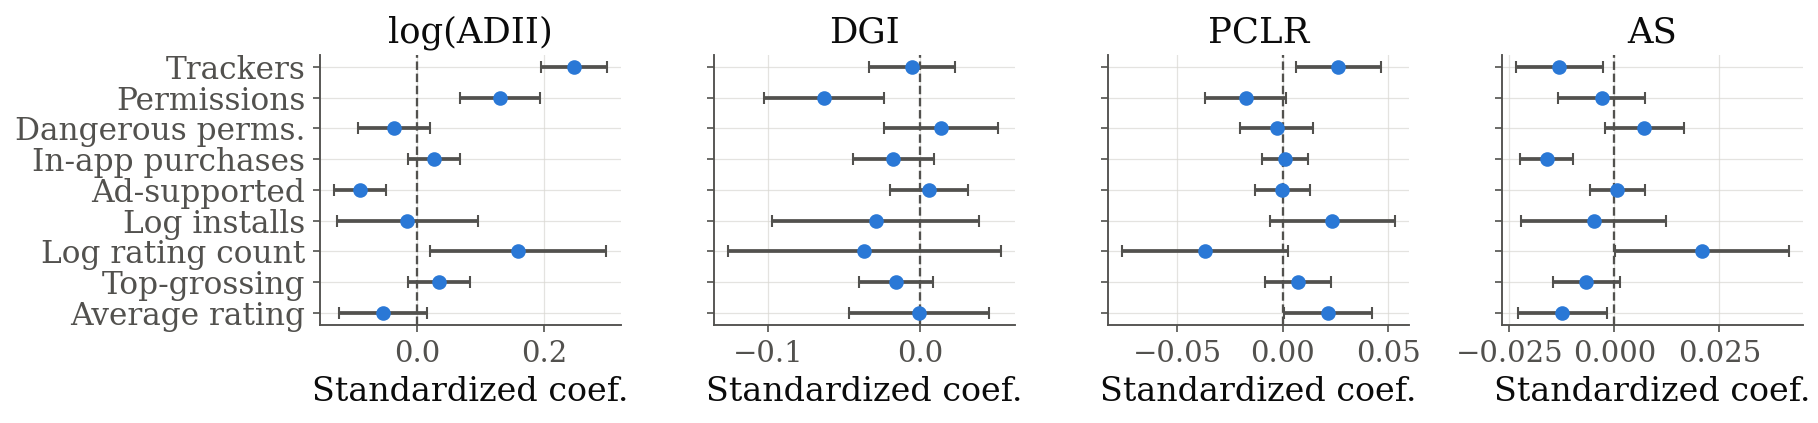

In [31]:
CATV = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
GRID_COLOR = "#d9d8d3"

plt.rcParams.update({
    "font.size": 16,
    "font.family": "serif",
    "axes.titlesize": 17,
    "axes.labelsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
    "axes.edgecolor": TEXT_SECONDARY,
    "axes.labelcolor": TEXT_PRIMARY,
    "text.color": TEXT_PRIMARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "lines.linewidth": 1.8,
    "pdf.fonttype": 42,
    "figure.dpi": 150,
})

reg_df = df.groupby("app_id").agg(
    ADII=("ADII", "mean"), PCLR=("PCLR", "mean"), AS=("AS", "mean"),
    num_trackers=("num_trackers", "first"), num_permissions=("num_permissions", "first"),
    num_dangerous_permissions=("num_dangerous_permissions", "first"),
    offersIAP=("offersIAP", "first"), ad_supported=("ad_supported", "first"),
    downloads_int=("downloads_int", "first"), ratings_count=("ratings_count", "first"),
    average_score=("average_score", "first"), top_grossing=("top_grossing", "first"),
    category=("category", "first"),
).dropna(subset=["ADII", "PCLR", "AS"])

app_dgi = df.groupby("app_id")["DGI"].mean().dropna()
reg_df = reg_df.join(app_dgi.rename("DGI_canon"))

reg_df["log_ADII"] = np.log1p(reg_df["ADII"])
reg_df["log_downloads"] = np.log1p(reg_df["downloads_int"])
reg_df["log_ratings"] = np.log1p(reg_df["ratings_count"].fillna(0))
reg_df["top_grossing_bin"] = (reg_df["top_grossing"] == "Yes").astype(int)
reg_df["offersIAP"] = reg_df["offersIAP"].astype(int)
reg_df["ad_supported"] = reg_df["ad_supported"].astype(int)

FOCUS = ["num_trackers", "num_permissions", "num_dangerous_permissions",
         "offersIAP", "ad_supported", "log_downloads", "log_ratings",
         "top_grossing_bin", "average_score"]
FOCUS_LABELS = ["Trackers", "Permissions", "Dangerous perms.", "In-app purchases",
                 "Ad-supported", "Log installs", "Log rating count",
                 "Top-grossing", "Average rating"]
for c in FOCUS:
    reg_df[f"z_{c}"] = (reg_df[c] - reg_df[c].mean()) / reg_df[c].std()
Z = [f"z_{c}" for c in FOCUS]

outcomes = [("log_ADII", "log(ADII)"), ("DGI_canon", "DGI"), ("PCLR", "PCLR"), ("AS", "AS")]
fig, axes = plt.subplots(1, 4, figsize=(12.4, 3.1), sharey=True)
for ax, (outcome, label) in zip(axes, outcomes):
    sub = reg_df.dropna(subset=[outcome] + Z)
    formula = f"{outcome} ~ " + " + ".join(Z) + " + C(category)"
    model = smf.ols(formula, data=sub).fit(cov_type="HC3")
    coefs = model.params[Z]
    ci = model.conf_int().loc[Z]
    ypos = np.arange(len(Z))[::-1]
    ax.errorbar(coefs.values, ypos, xerr=[coefs.values - ci[0].values, ci[1].values - coefs.values],
                fmt="o", color=CATV[0], ecolor=TEXT_SECONDARY, capsize=3, markersize=6)
    ax.axvline(0, color=TEXT_SECONDARY, linestyle="--", linewidth=1.1)
    ax.set_title(label)
    ax.set_xlabel("Standardized coef.")
    ax.tick_params(axis="x", labelsize=14)
axes[0].set_yticks(np.arange(len(Z))[::-1])
axes[0].set_yticklabels(FOCUS_LABELS, fontsize=15)
fig.tight_layout()
fig.savefig(FIG_DIR / "app_level_ols_coefficients.pdf", format="pdf", bbox_inches="tight")
plt.show()


## 10. Panel-style sensitivity analysis

Because each app is observed across multiple countries, we add two robustness checks:

1. **GEE with exchangeable correlation grouped by app**  
   This captures within-app dependence across repeated country observations without requiring the stronger distributional assumptions of a mixed-effects model.

2. **Fixed-effects-style OLS with app and country indicators**  
   This absorbs stable app-specific differences and isolates country-level contrasts.

These are treated as **sensitivity analyses**, not replacements for the main models above.


In [32]:

gee_results = []
gee_models = {}

gee_targets = ["log_ADII", "DGI", "PCLR"]
for target in gee_targets:
    formula = (
        f"{target} ~ z_log_downloads_for_model + z_log_ratings_count + z_average_score + "
        f"z_log_num_permissions + z_log_num_dangerous_permissions + z_log_num_trackers + "
        f"offersIAP_bin + ad_supported_bin + top_grossing_bin + C(categories) + C(region)"
    )
    gee_input = context_model_df.copy().replace([np.inf, -np.inf], np.nan).dropna(subset=[target, "app_id"])
    model = smf.gee(
        formula=formula,
        groups="app_id",
        data=gee_input,
        family=sm.families.Gaussian(),
        cov_struct=sm.cov_struct.Exchangeable(),
    ).fit()
    gee_models[target] = model
    gee_results.append(tidy_ols_result(model, "GEE (grouped by app)", target))
    print(f"===== GEE model: {target} =====")
    display(pd.DataFrame({
        "coef": model.params,
        "std_err": model.bse,
        "p_value": model.pvalues
    }).round(4).head(20))

gee_results = pd.concat(gee_results, ignore_index=True)
gee_results.head()


===== GEE model: log_ADII =====


,coef,std_err,p_value
Intercept,4.6556,0.1027,0.0000
C(categories)[T.Food & Drink],0.1793,0.1703,0.2924
C(categories)[T.Health & Fitness],0.0180,0.0973,0.8530
C(categories)[T.Lifestyle],-0.1335,0.1284,0.2985
C(categories)[T.Medical],-0.1701,0.1007,0.0912
C(categories)[T.Parenting],0.0760,0.1541,0.6218
C(categories)[T.Productivity],-0.2708,0.2493,0.2774
C(region)[T.Asia],0.0442,0.0169,0.0090
C(region)[T.Europe],0.2000,0.0161,0.0000
C(region)[T.Latin America],0.0728,0.0163,0.0000


===== GEE model: DGI =====


,coef,std_err,p_value
Intercept,0.3594,0.0729,0.0000
C(categories)[T.Food & Drink],0.0633,0.1320,0.6316
C(categories)[T.Health & Fitness],-0.1040,0.0715,0.1460
C(categories)[T.Lifestyle],0.0081,0.1002,0.9353
C(categories)[T.Medical],-0.0861,0.0752,0.2522
C(categories)[T.Parenting],-0.1566,0.0877,0.0740
C(categories)[T.Productivity],0.3887,0.1514,0.0103
C(region)[T.Asia],-0.0016,0.0024,0.4982
C(region)[T.Europe],-0.0090,0.0031,0.0043
C(region)[T.Latin America],-0.0037,0.0029,0.1936


===== GEE model: PCLR =====


,coef,std_err,p_value
Intercept,0.2295,0.0208,0.0000
C(categories)[T.Food & Drink],-0.0015,0.0694,0.9823
C(categories)[T.Health & Fitness],0.0638,0.0195,0.0010
C(categories)[T.Lifestyle],0.0413,0.0308,0.1794
C(categories)[T.Medical],0.0241,0.0193,0.2130
C(categories)[T.Parenting],-0.0067,0.0418,0.8718
C(categories)[T.Productivity],0.1444,0.0300,0.0000
C(region)[T.Asia],-0.0343,0.0102,0.0008
C(region)[T.Europe],0.0036,0.0092,0.6930
C(region)[T.Latin America],-0.0211,0.0096,0.0290


,term,coef,std_err,t_or_z,p_value,ci_low,ci_high,model,outcome,nobs,r_squared,pseudo_r2
0,Intercept,4.655584,0.102696,45.333807,0.000000,4.454304,4.856863,GEE (grouped by app),log_ADII,22529,NaN,NaN
1,C(categories)[T.Food & Drink],0.179347,0.170325,1.052969,0.292355,-0.154484,0.513178,GEE (grouped by app),log_ADII,22529,NaN,NaN
2,C(categories)[T.Health & Fitness],0.018032,0.097309,0.185304,0.852990,-0.172690,0.208754,GEE (grouped by app),log_ADII,22529,NaN,NaN
3,C(categories)[T.Lifestyle],-0.133540,0.128440,-1.039703,0.298478,-0.385278,0.118199,GEE (grouped by app),log_ADII,22529,NaN,NaN
4,C(categories)[T.Medical],-0.170127,0.100730,-1.688936,0.091232,-0.367554,0.027301,GEE (grouped by app),log_ADII,22529,NaN,NaN


In [33]:

fe_summaries = {}

fe_targets = [m for m in ["log_ADII", "DGI", "PCLR"] if m in context_model_df.columns]

for target in fe_targets:
    formula = f"{target} ~ C(app_id) + C(country_label)"
    fe_input = context_model_df.dropna(subset=[target]).copy()

    try:
        fe_model = smf.ols(formula, data=fe_input).fit(cov_type="HC3")
        core_terms = [t for t in fe_model.params.index if not t.startswith("C(app_id)")]
        fe_table = pd.DataFrame({
            "term": core_terms,
            "coef": [fe_model.params[t] for t in core_terms],
            "p_value": [fe_model.pvalues[t] for t in core_terms],
            "target": target,
            "n_obs": int(fe_model.nobs),
            "r_squared": float(fe_model.rsquared),
        })
        fe_summaries[target] = fe_table
        print(f"===== Fixed-effects-style model for {target} =====")
        display(fe_table.head(20))
    except Exception as e:
        print(f"Could not estimate fixed-effects model for {target}: {e}")

if fe_summaries:
    fe_results = pd.concat(fe_summaries.values(), ignore_index=True)
else:
    fe_results = pd.DataFrame()


===== Fixed-effects-style model for log_ADII =====


,term,coef,p_value,target,n_obs,r_squared
0,Intercept,4.177184,2.420220e-75,log_ADII,23392,0.545775
1,C(country_label)[T.Australia],0.165976,9.134927e-09,log_ADII,23392,0.545775
2,C(country_label)[T.Brazil],0.385172,2.315087e-32,log_ADII,23392,0.545775
3,C(country_label)[T.Canada],0.379455,2.085201e-40,log_ADII,23392,0.545775
4,C(country_label)[T.Chile],0.153001,2.461442e-06,log_ADII,23392,0.545775
5,C(country_label)[T.France],0.313433,2.047907e-27,log_ADII,23392,0.545775
6,C(country_label)[T.Germany],0.426622,2.301069e-53,log_ADII,23392,0.545775
7,C(country_label)[T.Great Britain],0.359313,5.668190e-23,log_ADII,23392,0.545775
8,C(country_label)[T.Greenland],0.040029,2.206733e-01,log_ADII,23392,0.545775
9,C(country_label)[T.India],0.137486,3.735190e-05,log_ADII,23392,0.545775


===== Fixed-effects-style model for DGI =====


,term,coef,p_value,target,n_obs,r_squared
0,Intercept,0.707470,3.620481e-46,DGI,23392,0.919125
1,C(country_label)[T.Australia],-0.001114,8.456904e-01,DGI,23392,0.919125
2,C(country_label)[T.Brazil],0.005047,3.863618e-01,DGI,23392,0.919125
3,C(country_label)[T.Canada],0.001411,8.122397e-01,DGI,23392,0.919125
4,C(country_label)[T.Chile],-0.002963,6.057241e-01,DGI,23392,0.919125
5,C(country_label)[T.France],-0.013842,1.682135e-02,DGI,23392,0.919125
6,C(country_label)[T.Germany],-0.009400,1.076331e-01,DGI,23392,0.919125
7,C(country_label)[T.Great Britain],0.013789,1.614852e-02,DGI,23392,0.919125
8,C(country_label)[T.Greenland],0.015368,5.987914e-03,DGI,23392,0.919125
9,C(country_label)[T.India],0.008813,1.170950e-01,DGI,23392,0.919125


===== Fixed-effects-style model for PCLR =====


,term,coef,p_value,target,n_obs,r_squared
0,Intercept,0.301282,9.715444e-04,PCLR,11967,0.467837
1,C(country_label)[T.Australia],0.026681,1.627764e-01,PCLR,11967,0.467837
2,C(country_label)[T.Brazil],0.035768,3.324865e-02,PCLR,11967,0.467837
3,C(country_label)[T.Canada],0.056216,9.769641e-04,PCLR,11967,0.467837
4,C(country_label)[T.Chile],0.048725,5.776791e-03,PCLR,11967,0.467837
5,C(country_label)[T.France],0.033021,3.609128e-02,PCLR,11967,0.467837
6,C(country_label)[T.Germany],0.099867,5.092314e-10,PCLR,11967,0.467837
7,C(country_label)[T.Great Britain],-0.010612,6.078355e-01,PCLR,11967,0.467837
8,C(country_label)[T.Greenland],0.102688,7.691976e-08,PCLR,11967,0.467837
9,C(country_label)[T.India],0.027156,1.919709e-01,PCLR,11967,0.467837



## 11. Monetization, popularity, permissions, and trackers

These summaries are not the main regression tables.  
Instead, they help interpret **which app characteristics tend to co-occur with higher privacy risk**.


In [34]:

biz_df = app_level.copy()

summary_frames = []
for flag_col, title in [
    ("ad_supported_bin", "Ads"),
    ("offersIAP_bin", "In-app purchases"),
]:
    if flag_col in biz_df.columns:
        metric_cols = [c for c in ["ADII", "DGI", "PCLR", "AS"] if c in biz_df.columns]
        tmp = (
            biz_df.groupby(flag_col)[metric_cols]
            .median()
            .reset_index()
        )
        tmp["grouping"] = title
        summary_frames.append(tmp)

if summary_frames:
    monetization_summary = pd.concat(summary_frames, ignore_index=True)
    display(monetization_summary)
else:
    monetization_summary = pd.DataFrame()
    print("No monetization flags available for summary tables.")


,ad_supported_bin,ADII,DGI,PCLR,AS,grouping,offersIAP_bin
0,0.0,120.500000,0.0,0.227273,0.379778,Ads,NaN
1,1.0,127.668462,0.0,0.230769,0.367290,Ads,NaN
2,NaN,104.016154,0.0,0.233333,0.407380,In-app purchases,0.0
3,NaN,134.423077,0.0,0.229167,0.367588,In-app purchases,1.0


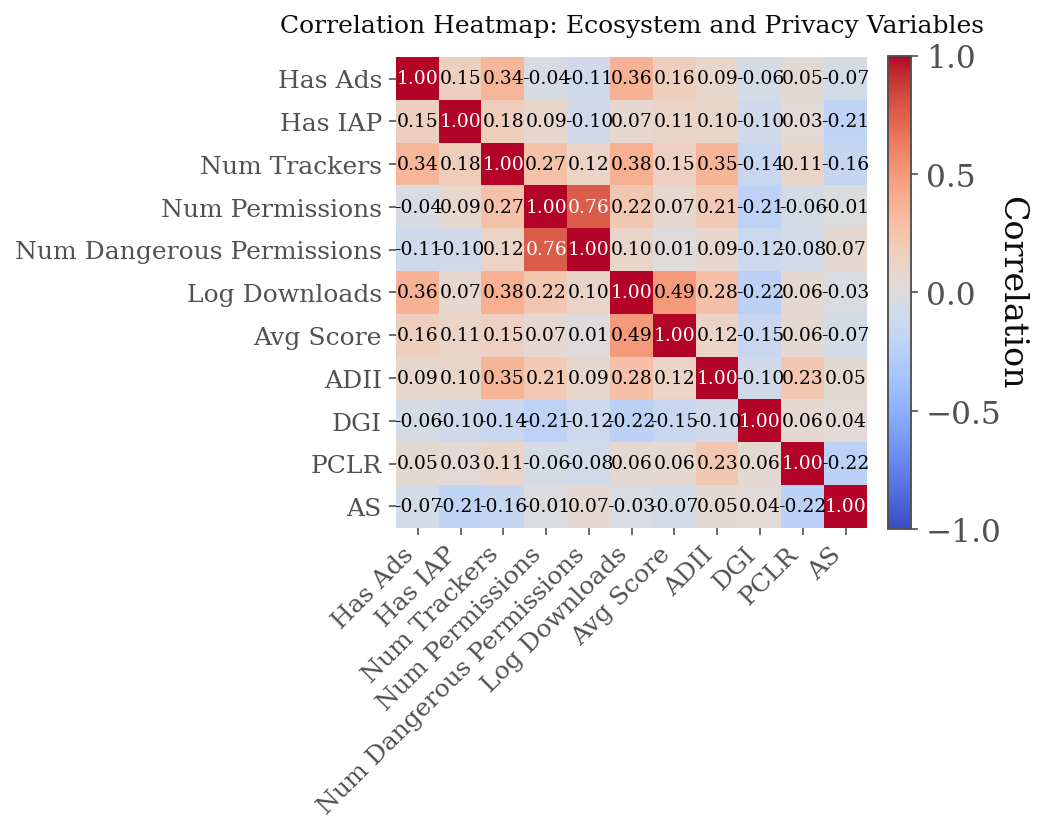

In [35]:

corr_cols = [c for c in [
    "ad_supported_bin", "offersIAP_bin",
    "num_trackers", "num_permissions", "num_dangerous_permissions",
    "log_downloads_for_model", "average_score",
    "ADII", "DGI", "PCLR", "AS"
] if c in biz_df.columns]

corr_df = biz_df[corr_cols].copy().dropna(how="all")

label_map = {
    "ad_supported_bin": "Has Ads",
    "offersIAP_bin": "Has IAP",
    "num_trackers": "Num Trackers",
    "num_permissions": "Num Permissions",
    "num_dangerous_permissions": "Num Dangerous Permissions",
    "log_downloads_for_model": "Log Downloads",
    "average_score": "Avg Score",
    "ADII": "ADII",
    "DGI": "DGI",
    "PCLR": "PCLR",
    "AS": "AS"
}

if len(corr_cols) >= 2:
    corr = corr_df.corr(numeric_only=True)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.grid(False)

    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="equal")

    labels = [label_map.get(c, c) for c in corr.columns]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=12)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=12)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title("Correlation Heatmap: Ecosystem and Privacy Variables", fontsize=12, pad=12)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Correlation", rotation=270, labelpad=12)

    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            val = corr.iloc[i, j]
            ax.text(
                j, i, f"{val:.2f}",
                ha="center", va="center",
                fontsize=9,
                color="white" if abs(val) > 0.5 else "black"
            )

    plt.tight_layout()
    plt.savefig(FIG_DIR / "privacy_businessmodel_correlation_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()



## 12. Regression-ready narrative helper

This final cell creates a compact machine-readable summary of direction and significance for the main OLS results.  

In [36]:

def direction_label(x):
    if x > 0:
        return "positive"
    if x < 0:
        return "negative"
    return "null"

narrative_rows = []
for outcome in ["log_ADII", "DGI", "PCLR", "AS"]:
    sub = ols_results[
        (ols_results["outcome"] == outcome) &
        (ols_results["term"].isin(focus_terms))
    ].copy()

    for _, row in sub.iterrows():
        narrative_rows.append({
            "outcome": outcome,
            "term": row["term"],
            "direction": direction_label(row["coef"]),
            "significant_0_05": bool(row["p_value"] < 0.05),
            "coef": round(row["coef"], 4),
            "p_value": round(row["p_value"], 6),
        })

narrative_df = pd.DataFrame(narrative_rows)
display(narrative_df)

print("Figures saved to:", FIG_DIR.resolve())


,outcome,term,direction,significant_0_05,coef,p_value
0,log_ADII,z_log_downloads_for_model,negative,False,-0.0515,0.412555
1,log_ADII,z_log_ratings_count,positive,True,0.2051,0.004529
2,log_ADII,z_average_score,negative,False,-0.0699,0.068484
3,log_ADII,z_log_num_permissions,positive,True,0.0689,0.031993
4,log_ADII,z_log_num_dangerous_permissions,negative,False,-0.0096,0.736567
5,log_ADII,z_log_num_trackers,positive,True,0.2823,0.000000
6,log_ADII,offersIAP_bin,positive,False,0.0544,0.261065
7,log_ADII,ad_supported_bin,negative,True,-0.2175,0.000007
8,log_ADII,top_grossing_bin,positive,False,0.0428,0.485855
9,DGI,z_log_downloads_for_model,positive,False,0.0004,0.992734


Figures saved to: /Users/iotlab3/Documents/mhealth/paper/figures
